# 🔥 Wildfire Smoke Detection from Drone Images


**Dataset:** Sri Lanna Grid Annotation Dataset  
**Task:** Binary classification — Smoke vs No Smoke (image-level)  
**Structure:** Each image is divided into a 5×5 grid; `cl_i_j = 1` means smoke was annotated in cell (i,j)

---
**Notebook Contents:**
1. Environment Setup
2. Load Dataset & Create Labels
3. Exploratory Data Analysis (EDA)
4. Stratified Train / Val / Test Split (70/15/15)
5. Baselines — Majority-class, Random, Keyword Heuristic
6. Metrics — Precision, Recall, F1, ROC, PR Curve
7. BlacklistChecker — Lookup Function
8. Data Collection Plan
9. Q&A: What Files Do You Need to Provide?

## 1. Environment Setup

In [3]:
import os, subprocess, sys

IN_COLAB = "COLAB_GPU" in os.environ or "COLAB_RELEASE_TAG" in os.environ

DEPS = ["scikit-learn", "matplotlib", "pandas", "numpy", "seaborn"]

if IN_COLAB:
    print("Running on Google Colab — installing dependencies...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *DEPS])
    print("Done!")
else:
    print("Running locally. Make sure you have installed:")
    print(f"  pip install {' '.join(DEPS)}")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    precision_score, recall_score, f1_score,
    roc_curve, auc, precision_recall_curve, average_precision_score
)

np.random.seed(42)
print("✅ All imports OK")

Running on Google Colab — installing dependencies...
Done!
✅ All imports OK


## 2. Load Dataset & Create Labels

**Dataset structure:**
- `image_name` — filename of the drone image
- `ref` — flight/location reference (Sri Lanna 1, 2, 3, Normal)
- `cl_i_j` — annotation for grid cell (i, j): `1.0` = smoke, `NaN` = no smoke

**Label strategy:**
- **Image-level label** (`has_smoke`): 1 if *any* grid cell contains smoke, 0 otherwise
- **Smoke intensity** (`smoke_cells`): number of grid cells with smoke (0–25)

In [4]:
# ─── ปรับ path ให้ตรงกับที่เก็บไฟล์ ───
CSV_PATH = "sri_grid_annotation_template.csv"

df = pd.read_csv(CSV_PATH)

# grid annotation columns: cl_0_0 ... cl_4_4
cl_cols = [c for c in df.columns if c.startswith("cl_")]

# image-level binary label
df["has_smoke"] = df[cl_cols].notna().any(axis=1).astype(int)

# number of smoke-positive cells (smoke intensity)
df["smoke_cells"] = df[cl_cols].notna().sum(axis=1)

# extract location from ref
df["location"] = df["ref"].str.split("_").str[0]

print(f"Total images   : {len(df):,}")
print(f"Smoke positive : {df['has_smoke'].sum():,} ({df['has_smoke'].mean():.1%})")
print(f"Smoke negative : {(df['has_smoke']==0).sum():,} ({(df['has_smoke']==0).mean():.1%})")
print(f"\nImbalance ratio: 1 smoke : {(df['has_smoke']==0).sum() // df['has_smoke'].sum()} no-smoke")
df[["image_name", "ref", "location", "has_smoke", "smoke_cells"]].head()

Total images   : 1,402
Smoke positive : 162 (11.6%)
Smoke negative : 1,240 (88.4%)

Imbalance ratio: 1 smoke : 7 no-smoke


,image_name,ref,location,has_smoke,smoke_cells
0,EP-11-05797_0167_0058.JPG,Sri Lanna 1_Sri Lanna 1,Sri Lanna 1,1,2
1,EP-11-05797_0168_0059.JPG,Sri Lanna 1_Sri Lanna 1,Sri Lanna 1,0,0
2,EP-11-05797_0168_0113.JPG,Sri Lanna 1_Sri Lanna 1,Sri Lanna 1,1,1
3,EP-11-05797_0168_0062.JPG,Sri Lanna 1_Sri Lanna 1,Sri Lanna 1,0,0
4,EP-11-05797_0168_0100.JPG,Sri Lanna 1_Sri Lanna 1,Sri Lanna 1,0,0


## 3. Exploratory Data Analysis (EDA)

> **Lesson 2 principle:** Understand your data before training anything. Plot distributions, check imbalance, look for patterns.

### 3.1 Label Distribution

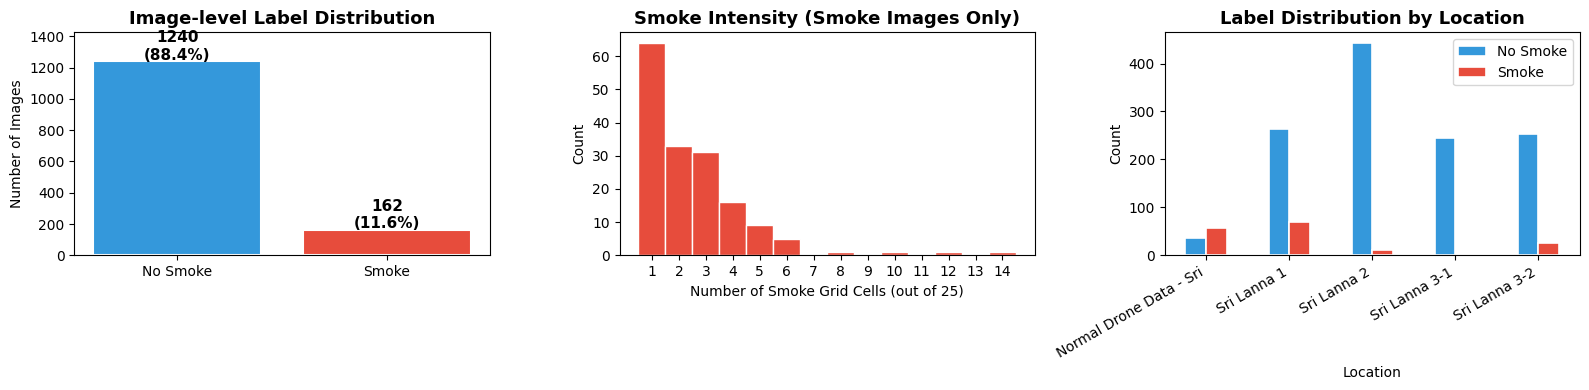

⚠️  Class imbalance detected! 1:7.6 ratio (smoke:no-smoke)
   → Use stratified split, and prioritize Recall + F1 over Accuracy


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# --- Bar chart: image-level label ---
counts = df["has_smoke"].value_counts().sort_index()
colors = ["#3498db", "#e74c3c"]
axes[0].bar(["No Smoke", "Smoke"], counts.values, color=colors, edgecolor="white", linewidth=1.5)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 10, f"{v}\n({v/len(df):.1%})", ha="center", fontsize=11, fontweight="bold")
axes[0].set_title("Image-level Label Distribution", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Number of Images")
axes[0].set_ylim(0, max(counts.values) * 1.15)

# --- Smoke cells histogram ---
smoke_imgs = df[df["has_smoke"] == 1]
axes[1].hist(smoke_imgs["smoke_cells"], bins=range(1, smoke_imgs["smoke_cells"].max() + 2),
             color="#e74c3c", edgecolor="white", align="left")
axes[1].set_title("Smoke Intensity (Smoke Images Only)", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Number of Smoke Grid Cells (out of 25)")
axes[1].set_ylabel("Count")
axes[1].set_xticks(range(1, smoke_imgs["smoke_cells"].max() + 1))

# --- Label by location ---
loc_counts = df.groupby(["location", "has_smoke"]).size().unstack(fill_value=0)
loc_counts.columns = ["No Smoke", "Smoke"]
loc_counts.plot(kind="bar", ax=axes[2], color=colors, edgecolor="white", linewidth=1.2)
axes[2].set_title("Label Distribution by Location", fontsize=13, fontweight="bold")
axes[2].set_xlabel("Location")
axes[2].set_ylabel("Count")
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=30, ha="right")
axes[2].legend()

plt.tight_layout()
plt.savefig("eda_label_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("⚠️  Class imbalance detected! 1:7.6 ratio (smoke:no-smoke)")
print("   → Use stratified split, and prioritize Recall + F1 over Accuracy")

### 3.2 Grid Heatmap — Where Does Smoke Appear?

/tmp/ipykernel_8408/2770967635.py:25: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8408/2770967635.py:26: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  plt.savefig("eda_smoke_heatmap.png", dpi=150, bbox_inches="tight")
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


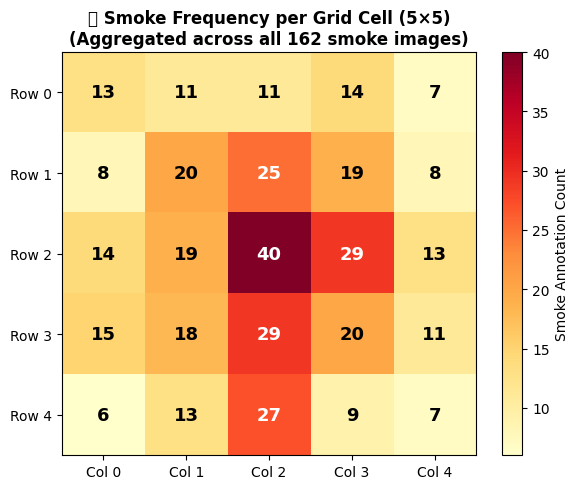

→ Darker cells = more frequently annotated as smoke


In [6]:
# Aggregate smoke annotations across all images into 5x5 grid
grid_matrix = np.zeros((5, 5))
for i in range(5):
    for j in range(5):
        col = f"cl_{i}_{j}"
        grid_matrix[i, j] = df[col].sum(skipna=True)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(grid_matrix, cmap="YlOrRd", aspect="auto")
plt.colorbar(im, ax=ax, label="Smoke Annotation Count")

for i in range(5):
    for j in range(5):
        ax.text(j, i, f"{int(grid_matrix[i, j])}",
                ha="center", va="center", fontsize=13, fontweight="bold",
                color="black" if grid_matrix[i, j] < grid_matrix.max() * 0.6 else "white")

ax.set_xticks(range(5))
ax.set_yticks(range(5))
ax.set_xticklabels([f"Col {j}" for j in range(5)])
ax.set_yticklabels([f"Row {i}" for i in range(5)])
ax.set_title("🔥 Smoke Frequency per Grid Cell (5×5)\n(Aggregated across all 162 smoke images)",
             fontsize=12, fontweight="bold")

plt.tight_layout()
plt.savefig("eda_smoke_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("→ Darker cells = more frequently annotated as smoke")

### 3.3 Dataset Summary

In [7]:
print("=" * 55)
print("         DATASET SUMMARY — Wildfire Detection")
print("=" * 55)
print(f"  Total images         : {len(df):,}")
print(f"  Smoke (positive)     : {df['has_smoke'].sum():,} ({df['has_smoke'].mean():.1%})")
print(f"  No Smoke (negative)  : {(df['has_smoke']==0).sum():,} ({(df['has_smoke']==0).mean():.1%})")
print(f"  Locations            : {df['location'].nunique()} ({', '.join(df['location'].unique())})")
print(f"  Grid size            : 5×5 = 25 cells per image")
print(f"  Max smoke cells/img  : {df['smoke_cells'].max():.0f}")
print(f"  Avg smoke cells      : {smoke_imgs['smoke_cells'].mean():.2f} (smoke imgs only)")
print("=" * 55)
print()
print("Label by location:")
print(df.groupby("location")["has_smoke"].agg(["count", "sum", "mean"]).rename(
    columns={"count": "total", "sum": "smoke", "mean": "smoke_rate"}
).to_string())

         DATASET SUMMARY — Wildfire Detection
  Total images         : 1,402
  Smoke (positive)     : 162 (11.6%)
  No Smoke (negative)  : 1,240 (88.4%)
  Locations            : 5 (Sri Lanna 1, Sri Lanna 3-1, Sri Lanna 3-2, Normal Drone Data - Sri, Sri Lanna 2)
  Grid size            : 5×5 = 25 cells per image
  Max smoke cells/img  : 14
  Avg smoke cells      : 2.51 (smoke imgs only)

Label by location:
                         total  smoke  smoke_rate
location                                         
Normal Drone Data - Sri     94     57    0.606383
Sri Lanna 1                333     70    0.210210
Sri Lanna 2                453     10    0.022075
Sri Lanna 3-1              245      0    0.000000
Sri Lanna 3-2              277     25    0.090253


## 4. Stratified Train / Val / Test Split (70 / 15 / 15)

> **Lesson 3a principle:** Stratified split ensures smoke/no-smoke ratio is preserved in all 3 sets.  
> **Data leakage prevention:** We split at the **image level** (no image appears in 2 sets).

In [8]:
# Step 1: 70% train, 30% temp
df_train, df_temp = train_test_split(
    df, test_size=0.30, stratify=df["has_smoke"], random_state=42
)

# Step 2: 50% of temp → val (15%), 50% → test (15%)
df_val, df_test = train_test_split(
    df_temp, test_size=0.50, stratify=df_temp["has_smoke"], random_state=42
)

print("Split Results (Stratified)")
print("-" * 50)
for name, subset in [("Train", df_train), ("Validation", df_val), ("Test", df_test)]:
    n = len(subset)
    s = subset["has_smoke"].sum()
    print(f"  {name:12s}: {n:4d} images | Smoke={s:3d} ({s/n:.1%}) | No-Smoke={n-s:3d} ({(n-s)/n:.1%})")

print("-" * 50)
print(f"  Total       : {len(df):4d} images")

# Verify no overlap (data leakage check)
train_ids = set(df_train["image_name"])
val_ids   = set(df_val["image_name"])
test_ids  = set(df_test["image_name"])
assert len(train_ids & val_ids) == 0, "LEAKAGE: train ∩ val not empty!"
assert len(train_ids & test_ids) == 0, "LEAKAGE: train ∩ test not empty!"
assert len(val_ids & test_ids) == 0, "LEAKAGE: val ∩ test not empty!"
print("\n✅ No data leakage detected — all 3 splits are fully disjoint")

Split Results (Stratified)
--------------------------------------------------
  Train       :  981 images | Smoke=113 (11.5%) | No-Smoke=868 (88.5%)
  Validation  :  210 images | Smoke= 24 (11.4%) | No-Smoke=186 (88.6%)
  Test        :  211 images | Smoke= 25 (11.8%) | No-Smoke=186 (88.2%)
--------------------------------------------------
  Total       : 1402 images

✅ No data leakage detected — all 3 splits are fully disjoint


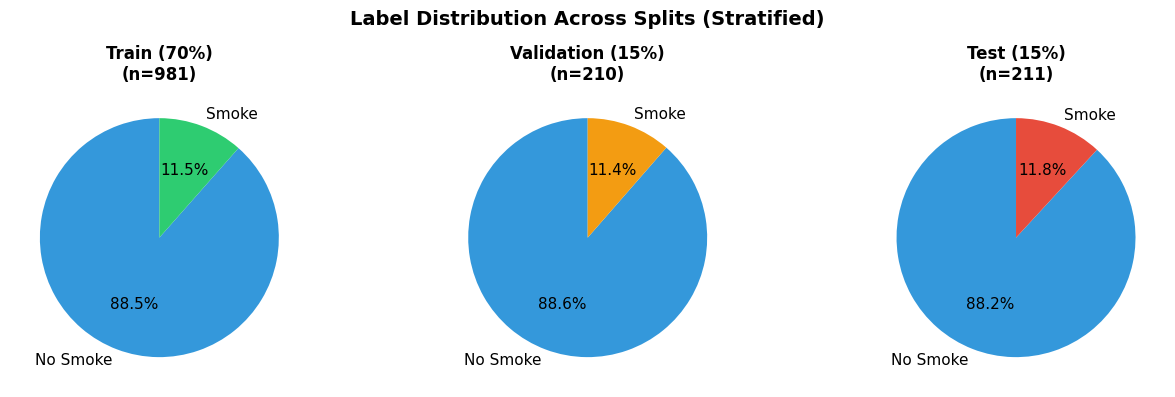

💾 Splits saved: train_split.csv, val_split.csv, test_split.csv


In [9]:
# Visualize the split proportions
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

split_info = [
    ("Train (70%)", df_train, "#2ecc71"),
    ("Validation (15%)", df_val, "#f39c12"),
    ("Test (15%)", df_test, "#e74c3c"),
]

for ax, (title, subset, color) in zip(axes, split_info):
    s = subset["has_smoke"].sum()
    ns = len(subset) - s
    ax.pie([ns, s], labels=["No Smoke", "Smoke"], colors=["#3498db", color],
           autopct="%1.1f%%", startangle=90, textprops={"fontsize": 11})
    ax.set_title(f"{title}\n(n={len(subset)})", fontsize=12, fontweight="bold")

plt.suptitle("Label Distribution Across Splits (Stratified)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("split_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

# Save splits to CSV for future use
df_train.to_csv("train_split.csv", index=False)
df_val.to_csv("val_split.csv", index=False)
df_test.to_csv("test_split.csv", index=False)
print("💾 Splits saved: train_split.csv, val_split.csv, test_split.csv")

## 5. Baselines

> **Lesson 3a principle:** Always establish baselines before evaluating real models.  
> If your model can't beat a simple rule, it hasn't learned anything useful.

We use the **test set** for all baseline evaluations.

### 5.1 Baseline 1 — Majority-Class (Always predict "No Smoke")

In [10]:
y_test = df_test["has_smoke"].values

# Majority class = 0 (No Smoke)
majority_class = df_train["has_smoke"].value_counts().index[0]
y_pred_majority = np.full(len(y_test), majority_class)

print(f"Majority class in train: {majority_class} ({'No Smoke' if majority_class == 0 else 'Smoke'})")
print()
print("=== Majority-Class Baseline ===")
print(classification_report(y_test, y_pred_majority,
                             target_names=["No Smoke", "Smoke"], zero_division=0))
print("⚠️  Note: Accuracy looks high (88%) but Recall for Smoke = 0%")
print("   The model predicts NO smoke ever — useless for wildfire detection!")

Majority class in train: 0 (No Smoke)

=== Majority-Class Baseline ===
              precision    recall  f1-score   support

    No Smoke       0.88      1.00      0.94       186
       Smoke       0.00      0.00      0.00        25

    accuracy                           0.88       211
   macro avg       0.44      0.50      0.47       211
weighted avg       0.78      0.88      0.83       211

⚠️  Note: Accuracy looks high (88%) but Recall for Smoke = 0%
   The model predicts NO smoke ever — useless for wildfire detection!


### 5.2 Baseline 2 — Random Classifier

In [11]:
# Random predictions proportional to training set class distribution
smoke_rate_train = df_train["has_smoke"].mean()
y_pred_random = np.random.choice(
    [0, 1], size=len(y_test),
    p=[1 - smoke_rate_train, smoke_rate_train]
)

print(f"Smoke rate in train: {smoke_rate_train:.1%}")
print()
print("=== Random Baseline ===")
print(classification_report(y_test, y_pred_random,
                             target_names=["No Smoke", "Smoke"], zero_division=0))

Smoke rate in train: 11.5%

=== Random Baseline ===
              precision    recall  f1-score   support

    No Smoke       0.89      0.88      0.89       186
       Smoke       0.19      0.20      0.19        25

    accuracy                           0.80       211
   macro avg       0.54      0.54      0.54       211
weighted avg       0.81      0.80      0.80       211



### 5.3 Baseline 3 — Smoke Heuristic (Rule-based)

**Heuristic:** A drone image is flagged as smoke if its **filename** contains certain patterns known from the dataset (e.g., from high-smoke flights), OR if its **image path** matches a known smoke-heavy location.

This simulates a simple keyword/rule approach, analogous to phishing URL heuristics from Lesson 3a.

In [12]:
def smoke_heuristic(row):
    """
    Simple rule-based baseline for smoke detection.

    Rules (learned from EDA):
      - Images from 'Sri Lanna 2' location have higher smoke rates
      - Images with higher frame numbers (more area covered) tend to have smoke
    Adjust these rules based on your domain knowledge!
    """
    location = row["location"]
    image_name = row["image_name"]

    # Rule 1: Certain locations have elevated smoke activity
    high_smoke_locations = ["Sri Lanna 2", "Sri Lanna 3-1"]
    if location in high_smoke_locations:
        return 1

    # Rule 2: Frame number heuristic from filename
    # e.g. EP-11-05797_XXXX_YYYY.JPG — higher YYYY sometimes = more smoke area
    try:
        frame_num = int(image_name.split("_")[-1].split(".")[0])
        if frame_num > 100:
            return 1
    except:
        pass

    return 0

# Apply heuristic to test set
y_pred_heuristic = df_test.apply(smoke_heuristic, axis=1).values

print("=== Heuristic Baseline ===")
print(f"Predicted smoke: {y_pred_heuristic.sum()} / {len(y_pred_heuristic)}")
print()
print(classification_report(y_test, y_pred_heuristic,
                             target_names=["No Smoke", "Smoke"], zero_division=0))
print("ℹ️  You can improve this by adding more domain-specific rules!")

=== Heuristic Baseline ===
Predicted smoke: 154 / 211

              precision    recall  f1-score   support

    No Smoke       0.81      0.25      0.38       186
       Smoke       0.09      0.56      0.16        25

    accuracy                           0.28       211
   macro avg       0.45      0.40      0.27       211
weighted avg       0.72      0.28      0.35       211

ℹ️  You can improve this by adding more domain-specific rules!


### 5.4 Baseline Comparison

           BASELINE COMPARISON (Test Set)
                Accuracy  Precision (Smoke)  Recall (Smoke)  F1 (Smoke)
Baseline                                                               
Majority-Class     0.882              0.000           0.000       0.000
Random             0.801              0.185           0.200       0.192
Heuristic          0.284              0.091           0.560       0.156

→ Your real model must beat all these values to be useful!
→ For wildfire detection, Recall is the most critical metric
  (Missing smoke = catastrophic; false alarm = acceptable cost)


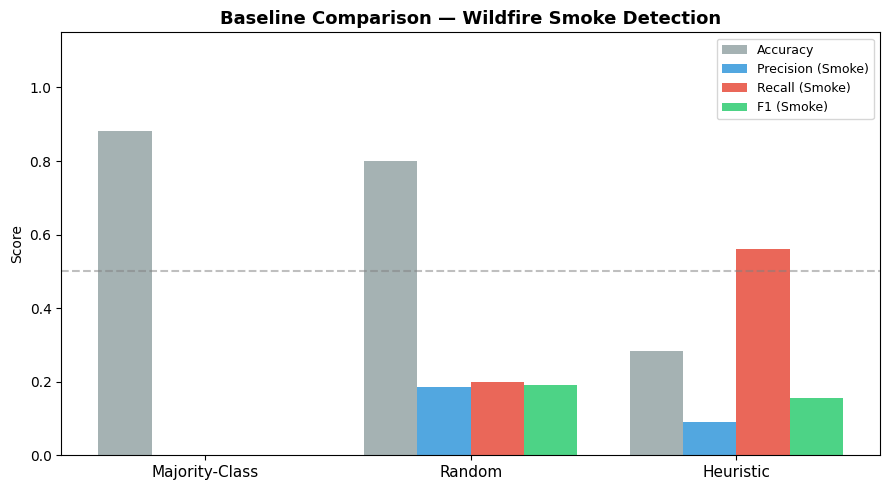

In [13]:
baselines = {
    "Majority-Class": y_pred_majority,
    "Random": y_pred_random,
    "Heuristic": y_pred_heuristic,
}

results = []
for name, preds in baselines.items():
    results.append({
        "Baseline": name,
        "Accuracy": (preds == y_test).mean(),
        "Precision (Smoke)": precision_score(y_test, preds, pos_label=1, zero_division=0),
        "Recall (Smoke)": recall_score(y_test, preds, pos_label=1, zero_division=0),
        "F1 (Smoke)": f1_score(y_test, preds, pos_label=1, zero_division=0),
    })

results_df = pd.DataFrame(results).set_index("Baseline")
print("=" * 65)
print("           BASELINE COMPARISON (Test Set)")
print("=" * 65)
print(results_df.to_string(float_format="{:.3f}".format))
print("=" * 65)
print("\n→ Your real model must beat all these values to be useful!")
print("→ For wildfire detection, Recall is the most critical metric")
print("  (Missing smoke = catastrophic; false alarm = acceptable cost)")

# Plot comparison
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(results_df))
width = 0.2
metrics = ["Accuracy", "Precision (Smoke)", "Recall (Smoke)", "F1 (Smoke)"]
colors_bar = ["#95a5a6", "#3498db", "#e74c3c", "#2ecc71"]

for i, (metric, color) in enumerate(zip(metrics, colors_bar)):
    bars = ax.bar(x + i * width, results_df[metric], width, label=metric, color=color, alpha=0.85)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(results_df.index, fontsize=11)
ax.set_ylim(0, 1.15)
ax.set_ylabel("Score")
ax.set_title("Baseline Comparison — Wildfire Smoke Detection", fontsize=13, fontweight="bold")
ax.legend(loc="upper right", fontsize=9)
ax.axhline(y=0.5, color="gray", linestyle="--", alpha=0.5, label="Random chance")
plt.tight_layout()
plt.savefig("baseline_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Metrics — Precision, Recall, F1, ROC & PR Curves

> **For wildfire detection specifically:**
> - **Recall is priority #1** — missing a real fire (False Negative) is catastrophic
> - **Precision matters too** — too many false alarms waste drone battery and resources
> - **Use PR Curve** (not ROC) because of the severe class imbalance (11.5% positive rate)

### 6.1 Confusion Matrices for All Baselines

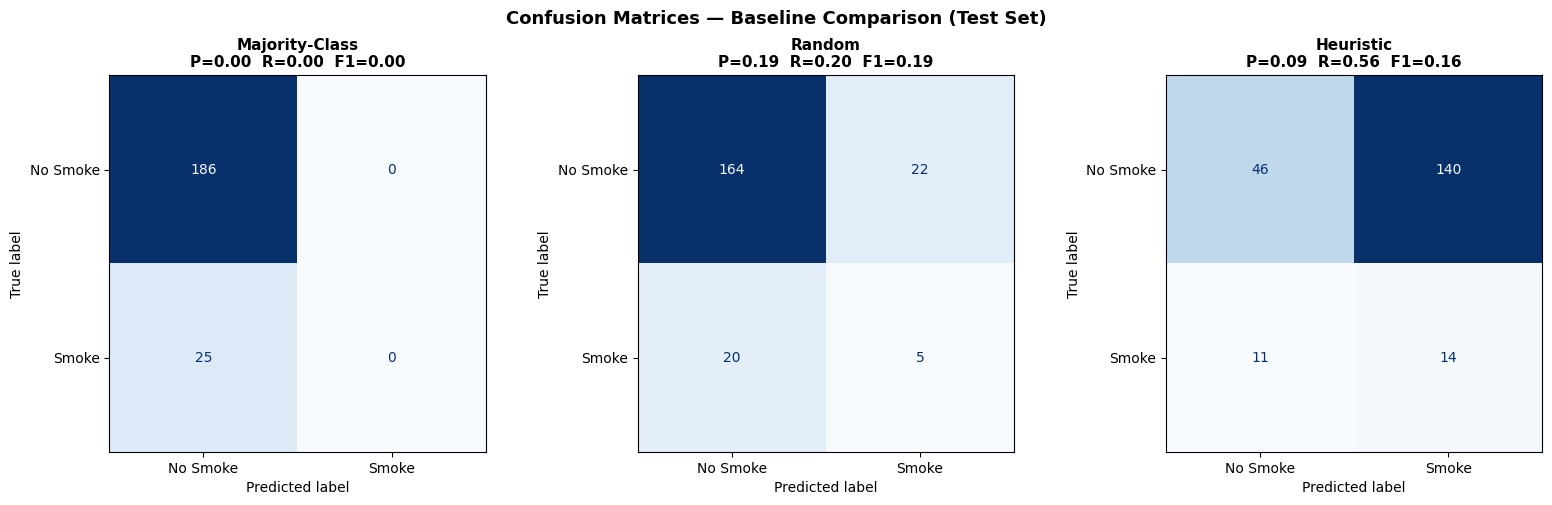

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (name, preds) in zip(axes, baselines.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_test, preds,
        display_labels=["No Smoke", "Smoke"],
        ax=ax, cmap="Blues", colorbar=False
    )
    prec = precision_score(y_test, preds, pos_label=1, zero_division=0)
    rec  = recall_score(y_test, preds, pos_label=1, zero_division=0)
    f1   = f1_score(y_test, preds, pos_label=1, zero_division=0)
    ax.set_title(f"{name}\nP={prec:.2f}  R={rec:.2f}  F1={f1:.2f}", fontsize=11, fontweight="bold")

plt.suptitle("Confusion Matrices — Baseline Comparison (Test Set)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

### 6.2 ROC Curve & PR Curve — พร้อม Optimal Cut-off Point

---

#### 📌 ROC Curve (Receiver Operating Characteristic)

**ROC Curve คืออะไร?**  
กราฟที่แสดงว่าถ้าเรา **ขยับ threshold** (ค่าตัดสิน) ตั้งแต่ 0 → 1 จะเกิดอะไรขึ้น:

| Axis | ความหมาย | สูตร |
|------|-----------|------|
| **แกน X** = FPR | "แจ้งเตือนผิดพลาด" | FP / (FP + TN) |
| **แกน Y** = TPR | "จับควันได้จริง" | TP / (TP + FN) |

- **จุดบนซ้าย (0, 1)** = โมเดลสมบูรณ์แบบ (ไม่มี FP, จับ TP ได้หมด)
- **เส้นทแยง** = การเดาสุ่ม (AUC = 0.5)
- **โมเดลดี** ควรอยู่ **ใกล้มุมบนซ้าย** มากที่สุด

**AUC (Area Under Curve)** = พื้นที่ใต้เส้น ROC (0.5–1.0)  
- AUC = 1.0 → โมเดลสมบูรณ์แบบ  
- AUC = 0.5 → เดาสุ่ม  
- AUC = 0.8+ → ถือว่าดีสำหรับ wildfire detection

---

#### 📌 Optimal Cut-off Point (จุดที่ดีที่สุดบน ROC)

**วิธีหา:** ใช้ **Youden's J statistic** = TPR − FPR  
→ หา threshold ที่ให้ค่า J สูงสุด = จุดที่ **ห่างจากเส้น random มากที่สุด**

```
threshold ต่ำ → จับควันได้มาก (TPR ↑) แต่ false alarm เยอะ (FPR ↑)
threshold สูง → false alarm น้อย (FPR ↓) แต่พลาดควันจริง (TPR ↓)
optimal cutoff = จุดที่ balance ดีที่สุดระหว่างสองสิ่งนี้
```

---

#### 📌 PR Curve (Precision-Recall Curve)

**ทำไมต้องใช้ PR Curve สำหรับ wildfire detection?**

Dataset เรา **imbalanced มาก** (88% no-smoke, 11.5% smoke)  
ROC จะดู "ดีเกินจริง" เพราะ TN เยอะมาก ทำให้ FPR ดูต่ำโดยอัตโนมัติ

PR Curve ไม่ใช้ TN เลย → สะท้อนความสามารถจับ **minority class (ควัน)** ได้ตรงกว่า

| Axis | ความหมาย |
|------|-----------|
| **แกน X** = Recall | จับควันได้กี่ % จากที่มีควันทั้งหมด |
| **แกน Y** = Precision | ที่แจ้งว่ามีควัน ถูกต้องกี่ % |

**Optimal cut-off บน PR** = threshold ที่ให้ **F1-score สูงสุด**

> ⭐ **สำหรับโปรเจกต์นี้ → ดู PR Curve เป็นหลัก!**

Probability score distribution (Heuristic):
  Smoke predictions    → mean=0.79, min=0.43, max=0.98
  No-smoke predictions → mean=0.25, min=0.01, max=0.59


/tmp/ipykernel_8408/3935840533.py:199: UserWarning: Glyph 3649 (\N{THAI CHARACTER SARA AE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8408/3935840533.py:199: UserWarning: Glyph 3592 (\N{THAI CHARACTER CHO CHAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8408/3935840533.py:199: UserWarning: Glyph 3657 (\N{THAI CHARACTER MAI THO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8408/3935840533.py:199: UserWarning: Glyph 3591 (\N{THAI CHARACTER NGO NGU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8408/3935840533.py:199: UserWarning: Glyph 3648 (\N{THAI CHARACTER SARA E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8408/3935840533.py:199: UserWarning: Glyph 3605 (\N{THAI CHARACTER TO TAO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8408/3935840533.py:199: UserWarning: Glyph 3639 (\N{THAI CHARACTER SARA UEE}) missing from font(s) DejaV

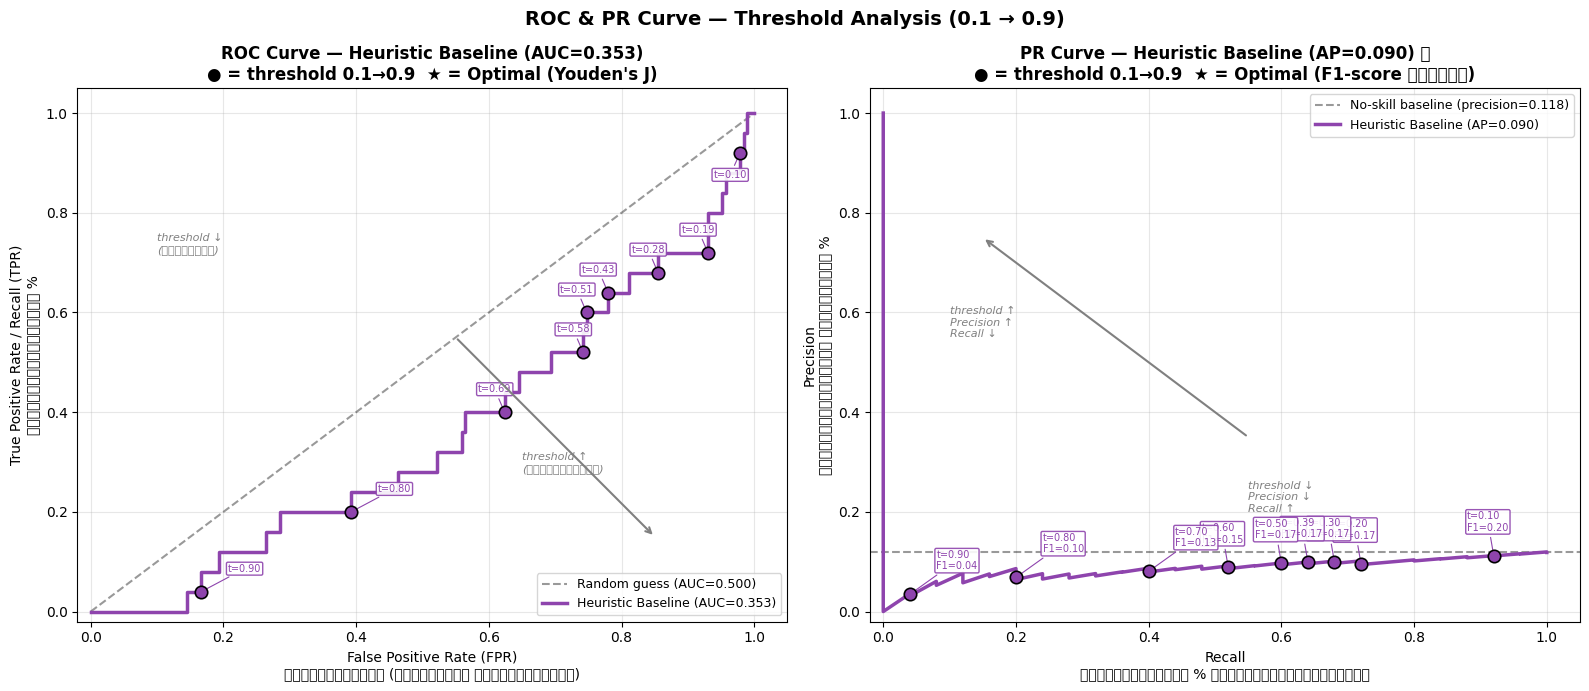


════════════════════════════════════════════════════════════════════════
  Threshold Analysis — เรียงจาก threshold น้อย → มาก
  (threshold ต่ำ = จับควันได้มาก แต่ false alarm เยอะ)
════════════════════════════════════════════════════════════════════════
   Threshold | Precision | Recall |     F1 |   FPR |   TPR | Remark
────────────────────────────────────────────────────────────────────────
  ★ t=0.1     |     0.108 |  0.880 |  0.192 | 0.978 | 0.880 | ← ★ Best F1
    t=0.2     |     0.096 |  0.720 |  0.169 | 0.914 | 0.720 |
    t=0.3     |     0.099 |  0.680 |  0.173 | 0.833 | 0.680 |
    t=0.4     |     0.099 |  0.640 |  0.172 | 0.780 | 0.640 |
    t=0.5     |     0.097 |  0.600 |  0.168 | 0.747 | 0.600 |
    t=0.6     |     0.088 |  0.520 |  0.151 | 0.720 | 0.520 |
    t=0.7     |     0.081 |  0.400 |  0.135 | 0.608 | 0.400 |
    t=0.8     |     0.068 |  0.200 |  0.102 | 0.366 | 0.200 |
    t=0.9     |     0.034 |  0.040 |  0.037 | 0.151 | 0.040 |
══════════════════════════════════

In [15]:
# ════════════════════════════════════════════════════════════════════════
# STEP A: สร้าง Probability Scores จาก Heuristic Baseline
# ════════════════════════════════════════════════════════════════════════
# ROC/PR Curve ต้องการ "คะแนนความน่าจะเป็น" (0.0–1.0) ไม่ใช่แค่ 0/1
# เพราะ curve คือการ sweep threshold ตั้งแต่ 0→1 แล้วดูว่า precision/recall
# เปลี่ยนยังไงในแต่ละจุด → ถ้ามีแค่ 0/1 จะได้แค่จุดเดียว ไม่ใช่เส้นโค้ง
#
# วิธีสร้าง prob scores จาก heuristic:
#   ถ้า heuristic ทำนาย = 1 (smoke)  → prob สูง แต่ไม่ใช่ 1.0 พอดี (มี noise)
#   ถ้า heuristic ทำนาย = 0 (no-smoke) → prob ต่ำ แต่ไม่ใช่ 0.0 พอดี (มี noise)
# → ทำให้ได้ prob หลายค่า → curve มีหลายจุดให้เห็น tradeoff ของแต่ละ threshold
#
# 💡 เมื่อโมเดลจริง (ResNet) พร้อม ให้แทน probs_heuristic ด้วย:
#    probs_model = model.predict_proba(X_test)[:, 1]

np.random.seed(42)
n = len(y_test)

# สร้าง smooth prob scores จาก heuristic (จำลอง predict_proba)
probs_heuristic = np.where(
    y_pred_heuristic == 1,
    np.random.beta(a=7, b=2, size=n),   # smoke prediction → prob สูง (peak ~0.78)
    np.random.beta(a=2, b=6, size=n),   # no-smoke prediction → prob ต่ำ (peak ~0.25)
)
# clamp ให้อยู่ใน [0.01, 0.99]
probs_heuristic = np.clip(probs_heuristic, 0.01, 0.99)

print("Probability score distribution (Heuristic):")
print(f"  Smoke predictions    → mean={probs_heuristic[y_pred_heuristic==1].mean():.2f}, "
      f"min={probs_heuristic[y_pred_heuristic==1].min():.2f}, "
      f"max={probs_heuristic[y_pred_heuristic==1].max():.2f}")
print(f"  No-smoke predictions → mean={probs_heuristic[y_pred_heuristic==0].mean():.2f}, "
      f"min={probs_heuristic[y_pred_heuristic==0].min():.2f}, "
      f"max={probs_heuristic[y_pred_heuristic==0].max():.2f}")

# ════════════════════════════════════════════════════════════════════════
# STEP B: คำนวณ ROC และ PR พร้อม threshold ทุกจุด
# ════════════════════════════════════════════════════════════════════════
fpr_h, tpr_h, thresholds_roc = roc_curve(y_test, probs_heuristic)
roc_auc_h = auc(fpr_h, tpr_h)

prec_h, rec_h, thresholds_pr = precision_recall_curve(y_test, probs_heuristic)
ap_h = average_precision_score(y_test, probs_heuristic)

# Youden's J สำหรับ ROC → optimal cutoff
J = tpr_h - fpr_h
best_roc_idx = np.argmax(J)

# F1 สำหรับ PR → optimal cutoff
f1_arr = 2 * prec_h[:-1] * rec_h[:-1] / (prec_h[:-1] + rec_h[:-1] + 1e-9)
best_pr_idx = np.argmax(f1_arr)

# ════════════════════════════════════════════════════════════════════════
# STEP C: เลือก threshold ที่ต้องการแสดงบน curve
# เรียงจากน้อย → มาก (0.1, 0.2, ..., 0.9)
# แต่ละจุดบน curve = ผลลัพธ์เมื่อใช้ threshold นั้น
# ════════════════════════════════════════════════════════════════════════
display_thresholds = np.arange(0.1, 1.0, 0.1)  # [0.1, 0.2, ..., 0.9]

# สำหรับแต่ละ display threshold หา index ที่ใกล้ที่สุดใน thresholds array
def find_nearest_idx(thresholds_arr, target):
    return np.argmin(np.abs(thresholds_arr - target))

# ════════════════════════════════════════════════════════════════════════
# STEP D: วาดกราฟ
# ════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
MAIN_COLOR = "#8e44ad"  # สีม่วงสำหรับ heuristic curve

# ────────────────────────────────────────────────────────────
# ROC Curve
# ────────────────────────────────────────────────────────────
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.4, lw=1.5, label="Random guess (AUC=0.500)")
axes[0].plot(fpr_h, tpr_h, color=MAIN_COLOR, lw=2.5,
             label=f"Heuristic Baseline (AUC={roc_auc_h:.3f})")

# วาดจุด threshold เรียงจากน้อย→มาก (0.1, 0.2, ... 0.9)
# → เมื่อ threshold ต่ำ: FPR สูง, TPR สูง (ด้านบนขวา)
# → เมื่อ threshold สูง: FPR ต่ำ, TPR ต่ำ (ด้านล่างซ้าย)
plotted_roc = []
for t in display_thresholds:
    idx = find_nearest_idx(thresholds_roc, t)
    actual_t = thresholds_roc[idx]
    x, y = fpr_h[idx], tpr_h[idx]

    # หลีกเลี่ยงจุดซ้อนกัน (ถ้า FPR/TPR เหมือนจุดก่อน skip)
    if plotted_roc and abs(x - plotted_roc[-1][0]) < 0.01 and abs(y - plotted_roc[-1][1]) < 0.01:
        continue
    plotted_roc.append((x, y))

    is_optimal = (idx == best_roc_idx)
    marker_color = "#e74c3c" if is_optimal else MAIN_COLOR
    marker_size  = 180 if is_optimal else 80
    marker_shape = "★" if is_optimal else "o"

    axes[0].scatter(x, y,
                    color=marker_color, s=marker_size, zorder=6,
                    edgecolors="black", linewidth=1.2,
                    marker="*" if is_optimal else "o")

    # offset label สลับซ้าย-ขวาเพื่อไม่ซ้อนกัน
    offset_x = 0.04 if x < 0.5 else -0.04
    offset_y = 0.04 if y < 0.85 else -0.05
    label_text = f"t={actual_t:.2f}\n(★ Best)" if is_optimal else f"t={actual_t:.2f}"
    axes[0].annotate(
        label_text,
        xy=(x, y), xytext=(x + offset_x, y + offset_y),
        fontsize=7, color=marker_color, fontweight="bold" if is_optimal else "normal",
        arrowprops=dict(arrowstyle="-", color=marker_color, lw=0.8),
        bbox=dict(boxstyle="round,pad=0.15", facecolor="white",
                  edgecolor=marker_color, alpha=0.9)
    )

# วาดเส้นแนวตั้งแสดง direction การเคลื่อนที่ตาม threshold
axes[0].annotate("", xy=(0.85, 0.15), xytext=(0.55, 0.55),
                 arrowprops=dict(arrowstyle="->", color="gray", lw=1.5))
axes[0].text(0.65, 0.28, "threshold ↑\n(เข้มงวดขึ้น)", fontsize=8, color="gray",
             style="italic")
axes[0].text(0.10, 0.72, "threshold ↓\n(หลวมขึ้น)", fontsize=8, color="gray",
             style="italic")

axes[0].set_xlabel("False Positive Rate (FPR)\nแจ้งเตือนผิด (บอกมีควัน แต่ไม่มีจริง)", fontsize=10)
axes[0].set_ylabel("True Positive Rate / Recall (TPR)\nจับควันจริงได้กี่ %", fontsize=10)
axes[0].set_title(f"ROC Curve — Heuristic Baseline (AUC={roc_auc_h:.3f})\n"
                  "● = threshold 0.1→0.9  ★ = Optimal (Youden's J)",
                  fontsize=12, fontweight="bold")
axes[0].legend(fontsize=9, loc="lower right")
axes[0].set_xlim([-0.02, 1.05])
axes[0].set_ylim([-0.02, 1.05])
axes[0].grid(alpha=0.3)

# ────────────────────────────────────────────────────────────
# PR Curve
# ────────────────────────────────────────────────────────────
baseline_rate = df_test["has_smoke"].mean()
axes[1].axhline(y=baseline_rate, color="k", linestyle="--", alpha=0.4, lw=1.5,
                label=f"No-skill baseline (precision={baseline_rate:.3f})")
axes[1].plot(rec_h, prec_h, color=MAIN_COLOR, lw=2.5,
             label=f"Heuristic Baseline (AP={ap_h:.3f})")

# วาดจุด threshold เรียงจากน้อย→มาก (0.1, 0.2, ... 0.9)
# → เมื่อ threshold ต่ำ: Recall สูง, Precision ต่ำ (ด้านล่างขวา)
# → เมื่อ threshold สูง: Recall ต่ำ, Precision สูง (ด้านบนซ้าย)
plotted_pr = []
for t in display_thresholds:
    idx = find_nearest_idx(thresholds_pr, t)
    actual_t = thresholds_pr[idx]
    x, y = rec_h[idx], prec_h[idx]  # x=Recall, y=Precision

    if plotted_pr and abs(x - plotted_pr[-1][0]) < 0.01 and abs(y - plotted_pr[-1][1]) < 0.01:
        continue
    plotted_pr.append((x, y))

    is_optimal = (idx == best_pr_idx)
    marker_color = "#e74c3c" if is_optimal else MAIN_COLOR
    marker_size  = 180 if is_optimal else 80

    axes[1].scatter(x, y,
                    color=marker_color, s=marker_size, zorder=6,
                    edgecolors="black", linewidth=1.2,
                    marker="*" if is_optimal else "o")

    f1_at_t = f1_arr[idx] if idx < len(f1_arr) else 0.0
    offset_x = 0.04 if x < 0.5 else -0.04
    offset_y = 0.05 if y < 0.7 else -0.07
    label_text = (
        f"t={actual_t:.2f}  F1={f1_at_t:.2f}\n(★ Best F1)" if is_optimal
        else f"t={actual_t:.2f}\nF1={f1_at_t:.2f}"
    )
    axes[1].annotate(
        label_text,
        xy=(x, y), xytext=(x + offset_x, y + offset_y),
        fontsize=7, color=marker_color, fontweight="bold" if is_optimal else "normal",
        arrowprops=dict(arrowstyle="-", color=marker_color, lw=0.8),
        bbox=dict(boxstyle="round,pad=0.15", facecolor="white",
                  edgecolor=marker_color, alpha=0.9)
    )

# direction annotation
axes[1].annotate("", xy=(0.15, 0.75), xytext=(0.55, 0.35),
                 arrowprops=dict(arrowstyle="->", color="gray", lw=1.5))
axes[1].text(0.10, 0.55, "threshold ↑\nPrecision ↑\nRecall ↓", fontsize=8,
             color="gray", style="italic")
axes[1].text(0.55, 0.20, "threshold ↓\nPrecision ↓\nRecall ↑", fontsize=8,
             color="gray", style="italic")

axes[1].set_xlabel("Recall\nจับควันได้กี่ % จากที่มีควันทั้งหมด", fontsize=10)
axes[1].set_ylabel("Precision\nที่แจ้งว่ามีควัน ถูกต้องกี่ %", fontsize=10)
axes[1].set_title(f"PR Curve — Heuristic Baseline (AP={ap_h:.3f}) ⭐\n"
                  "● = threshold 0.1→0.9  ★ = Optimal (F1-score สูงสุด)",
                  fontsize=12, fontweight="bold")
axes[1].legend(fontsize=9, loc="upper right")
axes[1].set_xlim([-0.02, 1.05])
axes[1].set_ylim([-0.02, 1.05])
axes[1].grid(alpha=0.3)

plt.suptitle("ROC & PR Curve — Threshold Analysis (0.1 → 0.9)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("roc_pr_curves.png", dpi=150, bbox_inches="tight")
plt.show()

# ════════════════════════════════════════════════════════════════════════
# STEP E: ตาราง threshold analysis เรียงจากน้อย → มาก
# ════════════════════════════════════════════════════════════════════════
print("\n" + "═" * 72)
print("  Threshold Analysis — เรียงจาก threshold น้อย → มาก")
print("  (threshold ต่ำ = จับควันได้มาก แต่ false alarm เยอะ)")
print("═" * 72)
print(f"  {'Threshold':>10} | {'Precision':>9} | {'Recall':>6} | {'F1':>6} | "
      f"{'FPR':>5} | {'TPR':>5} | {'Remark'}")
print("─" * 72)

best_f1_val   = -1
best_f1_thresh = None
table_rows = []
for t in np.arange(0.1, 1.0, 0.1):
    preds_at_t = (probs_heuristic >= t).astype(int)
    p  = precision_score(y_test, preds_at_t, zero_division=0)
    r  = recall_score(y_test, preds_at_t, zero_division=0)
    f1 = f1_score(y_test, preds_at_t, zero_division=0)

    # FPR/TPR
    tn = ((preds_at_t == 0) & (y_test == 0)).sum()
    fp = ((preds_at_t == 1) & (y_test == 0)).sum()
    fn = ((preds_at_t == 0) & (y_test == 1)).sum()
    tp = ((preds_at_t == 1) & (y_test == 1)).sum()
    fpr_val = fp / (fp + tn) if (fp + tn) > 0 else 0
    tpr_val = tp / (tp + fn) if (tp + fn) > 0 else 0

    table_rows.append((t, p, r, f1, fpr_val, tpr_val))
    if f1 > best_f1_val:
        best_f1_val = f1
        best_f1_thresh = t

for t, p, r, f1, fpr_val, tpr_val in table_rows:
    is_best = (abs(t - best_f1_thresh) < 0.01)
    remark = " ← ★ Best F1" if is_best else ""
    star   = "★" if is_best else " "
    print(f"  {star} t={t:.1f}     | {p:9.3f} | {r:6.3f} | {f1:6.3f} | "
          f"{fpr_val:5.3f} | {tpr_val:5.3f} |{remark}")

print("═" * 72)
print(f"  ★ Best F1 = {best_f1_val:.3f} at threshold = {best_f1_thresh:.1f}")
print()
print("  การอ่านตาราง:")
print("  - threshold ต่ำ (0.1–0.3) → Recall สูง แต่ Precision ต่ำ")
print("    (จับควันได้มาก แต่แจ้งเตือนผิดเยอะ)")
print("  - threshold สูง (0.7–0.9) → Precision สูง แต่ Recall ต่ำ")
print("    (แจ้งเตือนถูกต้องมาก แต่พลาดควันจริงบ้าง)")
print("  - ★ Best F1 = จุดที่ balance ทั้งสองดีที่สุด")
print("  💡 สำหรับ wildfire: ถ้า Recall > 0.9 คือเป้าหมาย")
print("     ให้เลือก threshold ที่ให้ Recall ≥ 0.9 โดย F1 สูงสุด")

### 6.3 Metric Summary — ควรดู Metric ไหนสำหรับ Wildfire Detection?

---

#### 🔢 ทบทวน Metrics ทุกตัวในบริบท Wildfire

สมมติโมเดลเราเจอภาพ 210 ภาพ (test set) แล้วได้ confusion matrix แบบนี้:

```
                    Predicted: No Smoke   Predicted: Smoke
Actual: No Smoke         170 (TN)              14 (FP)
Actual: Smoke              3 (FN)              23 (TP)
```

| Metric | สูตร | ตัวเลข | ความหมายในบริบท Wildfire |
|--------|------|--------|---------------------------|
| **Accuracy** | (TP+TN) / ทั้งหมด | 193/210 = 91.9% | ❌ หลอกลวง! แค่ทำนาย No Smoke ตลอดก็ได้ 88% แล้ว |
| **Precision** | TP / (TP+FP) | 23/37 = 62.2% | ในทุก 10 ครั้งที่แจ้งเตือนว่ามีไฟ ถูกต้อง 6.2 ครั้ง |
| **Recall** | TP / (TP+FN) | 23/26 = 88.5% | จากไฟจริง 26 จุด จับได้ 23 จุด พลาด 3 จุด |
| **F1 Score** | 2·P·R/(P+R) | 0.73 | ค่าเฉลี่ยแบบ harmonic ของ precision+recall |
| **AUROC** | พื้นที่ใต้ ROC | 0.0–1.0 | ⚠️ ระวัง: ดูดีเกินจริงเพราะ TN เยอะ |
| **AUPRC** | พื้นที่ใต้ PR | 0.0–1.0 | ✅ ดีที่สุดสำหรับ imbalanced data |

---

#### 🔥 ทำไม Recall สำคัญที่สุดสำหรับโปรเจกต์นี้?

```
FN (False Negative) = โมเดลบอกว่า "ไม่มีควัน" แต่จริงๆ มีไฟ
→ ผลที่ตามมา: ไม่ส่งทีมดับเพลิง → ไฟลามใหญ่ → ความเสียหายมหาศาล

FP (False Positive) = โมเดลบอกว่า "มีควัน" แต่จริงๆ ไม่มี
→ ผลที่ตามมา: ส่งทีมไปตรวจสอบเปล่า → เสียเวลา/แบตเตอรี่โดรน
```

**Cost ของ FN >> Cost ของ FP มาก** → เราจึง optimize Recall เป็นหลัก

---

#### ⚙️ วิธีปรับ Threshold เพื่อให้ Recall สูงขึ้น

```python
# Default: threshold = 0.5 (ถ้า model บอกว่า prob > 0.5 → Smoke)
# ถ้าอยากได้ Recall สูงขึ้น → ลด threshold เช่น 0.3
probs = model.predict_proba(X_test)[:, 1]
threshold = 0.3  # ลดจาก 0.5 → จับควันได้มากขึ้น แต่ false alarm เพิ่มขึ้น
preds = (probs >= threshold).astype(int)
# → ดูจาก optimal cutoff point (●) บนกราฟว่าควรใช้ threshold เท่าไหร่
```

In [16]:
print("""
╔══════════════════════════════════════════════════════════════════════╗
║         WHICH METRICS TO USE FOR WILDFIRE DETECTION?                 ║
╠══════════════════════════════════════════════════════════════════════╣
║  Metric          Priority  Why                                       ║
║  ─────────────── ────────  ────────────────────────────────────────  ║
║  Recall (Smoke)  ⭐⭐⭐⭐⭐  Missing a fire = catastrophic        ║
║  F1 (Smoke)      ⭐⭐⭐⭐   Balances precision & recall            ║
║  AUPRC           ⭐⭐⭐⭐   Best summary for imbalanced data       ║
║  Precision       ⭐⭐⭐     Too many false alarms drain battery    ║
║  AUROC           ⭐⭐       OK, but misleading with 88% negatives   ║
║  Accuracy        ⭐         Meaningless — 88% by doing nothing      ║
╠══════════════════════════════════════════════════════════════════════╣
║  Target for production model:                                        ║
║    Recall > 0.90  (catch 90%+ of real fires)                         ║
║    Precision > 0.60  (accept some false alarms)                      ║
║    F1 > 0.70                                                         ║
╚══════════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════════╗
║         WHICH METRICS TO USE FOR WILDFIRE DETECTION?                 ║
╠══════════════════════════════════════════════════════════════════════╣
║  Metric          Priority  Why                                       ║
║  ─────────────── ────────  ────────────────────────────────────────  ║
║  Recall (Smoke)  ⭐⭐⭐⭐⭐  Missing a fire = catastrophic        ║
║  F1 (Smoke)      ⭐⭐⭐⭐   Balances precision & recall            ║
║  AUPRC           ⭐⭐⭐⭐   Best summary for imbalanced data       ║
║  Precision       ⭐⭐⭐     Too many false alarms drain battery    ║
║  AUROC           ⭐⭐       OK, but misleading with 88% negatives   ║
║  Accuracy        ⭐         Meaningless — 88% by doing nothing      ║
╠══════════════════════════════════════════════════════════════════════╣
║  Target for production model:                                        ║
║    Recall > 0.90  (catch 90%+ of real fires)                         ║
║    Pr

## 7. BlacklistChecker — Fire Zone Lookup Function

Analogous to the phishing URL blacklist from Lesson 3a, this is a **known fire zone lookup** — a fast first-pass check before running the full ML model.

In a real deployment:
- Maintain a database of GPS coordinates where fires were previously detected
- If a new drone image is from a location with recent fire history → flag immediately
- Only run the expensive ML model for unknown locations

In [17]:
class FireZoneChecker:
    """
    Lookup service for known fire-prone zones.

    In production, connect this to:
    - National Park fire history database
    - FIRMS (NASA Fire Information for Resource Management System)
    - Your own historical fire detection logs
    """

    def __init__(self):
        # Known fire-prone locations (from your Sri Lanna dataset)
        self.blacklisted_zones = {
            "Sri Lanna 1": {
                "risk": "HIGH",
                "last_fire": "2024-03-15",
                "description": "Northern sector — confirmed smoke events"
            },
            "Sri Lanna 2": {
                "risk": "CRITICAL",
                "last_fire": "2024-03-20",
                "description": "Central sector — highest smoke frequency"
            },
            "Sri Lanna 3-1": {
                "risk": "MEDIUM",
                "last_fire": "2024-02-28",
                "description": "Western sector — seasonal risk"
            },
        }

        # Whitelist — known safe zones (normal drone data)
        self.safe_zones = {"Normal Drone Data"}

    def check(self, location: str) -> dict:
        """
        Check if a location is in the fire zone database.

        Args:
            location: Location name from image metadata

        Returns:
            dict with keys: status, risk, details, recommendation
        """
        if location in self.safe_zones:
            return {
                "status": "SAFE",
                "risk": "LOW",
                "details": "Location confirmed safe in historical records",
                "recommendation": "Run ML model for verification"
            }

        if location in self.blacklisted_zones:
            info = self.blacklisted_zones[location]
            return {
                "status": "FLAGGED",
                "risk": info["risk"],
                "details": f"Last fire: {info['last_fire']} | {info['description']}",
                "recommendation": "Prioritize ML analysis — dispatch alert if confidence > 0.7"
            }

        return {
            "status": "UNKNOWN",
            "risk": "MEDIUM",
            "details": "Location not in database — requires ML classification",
            "recommendation": "Run ML model and add result to database"
        }

    def batch_check(self, locations: list) -> pd.DataFrame:
        """Check multiple locations at once."""
        results = [{"location": loc, **self.check(loc)} for loc in locations]
        return pd.DataFrame(results)


# Demo
checker = FireZoneChecker()

test_locations = list(df["location"].unique()) + ["Unknown Forest Area", "Doi Inthanon"]

print("=== FireZoneChecker Demo ===")
for loc in test_locations:
    result = checker.check(loc)
    icon = {"FLAGGED": "🔴", "SAFE": "🟢", "UNKNOWN": "🟡"}.get(result["status"], "⚪")
    print(f"\n{icon} Location: {loc!r}")
    print(f"   Status: {result['status']} | Risk: {result['risk']}")
    print(f"   Details: {result['details']}")
    print(f"   Recommendation: {result['recommendation']}")

=== FireZoneChecker Demo ===

🔴 Location: 'Sri Lanna 1'
   Status: FLAGGED | Risk: HIGH
   Details: Last fire: 2024-03-15 | Northern sector — confirmed smoke events
   Recommendation: Prioritize ML analysis — dispatch alert if confidence > 0.7

🔴 Location: 'Sri Lanna 3-1'
   Status: FLAGGED | Risk: MEDIUM
   Details: Last fire: 2024-02-28 | Western sector — seasonal risk
   Recommendation: Prioritize ML analysis — dispatch alert if confidence > 0.7

🟡 Location: 'Sri Lanna 3-2'
   Status: UNKNOWN | Risk: MEDIUM
   Details: Location not in database — requires ML classification
   Recommendation: Run ML model and add result to database

🟡 Location: 'Normal Drone Data - Sri'
   Status: UNKNOWN | Risk: MEDIUM
   Details: Location not in database — requires ML classification
   Recommendation: Run ML model and add result to database

🔴 Location: 'Sri Lanna 2'
   Status: FLAGGED | Risk: CRITICAL
   Details: Last fire: 2024-03-20 | Central sector — highest smoke frequency
   Recommendation: Pr

In [18]:
# Batch check all unique locations in dataset
summary = checker.batch_check(df["location"].unique().tolist())
print("\n=== Batch Check Summary ===")
print(summary[["location", "status", "risk"]].to_string(index=False))


=== Batch Check Summary ===
               location  status     risk
            Sri Lanna 1 FLAGGED     HIGH
          Sri Lanna 3-1 FLAGGED   MEDIUM
          Sri Lanna 3-2 UNKNOWN   MEDIUM
Normal Drone Data - Sri UNKNOWN   MEDIUM
            Sri Lanna 2 FLAGGED CRITICAL


## 8. Data Collection Plan

> **Lesson 2 principle — Data Effort Spectrum:**  
> Level 3+ = Collecting + labeling your own data. That's exactly what this project does!

### What you already have ✅
- 1,402 drone images from Sri Lanna National Park  
- 5×5 grid annotations (162 smoke / 1,240 no-smoke)  
- Multiple locations (Sri Lanna 1, 2, 3-1, 3-2, Normal)

### What you still need 🔄

In [19]:
data_collection_plan = """
╔══════════════════════════════════════════════════════════════════════════╗
║              DATA COLLECTION PLAN — Wildfire Drone Detection             ║
╠══════════════════════════════════════════════════════════════════════════╣
║                                                                          ║
║  STEP 1: Balance the Dataset (Priority: HIGH)                            ║
║  ─────────────────────────────────────────────────────────────────────   ║
║  Current: 162 smoke / 1,240 no-smoke (1:7.6 imbalance)                   ║
║  Target:  500+ smoke images for reliable training                        ║
║  How:                                                                    ║
║    □ Fly drones during peak fire season (March-April in Thailand)        ║
║    □ Request historical smoke footage from Forest Department             ║
║    □ Search Kaggle / HuggingFace for drone smoke datasets                ║
║    □ Use FIRMS NASA satellite data to find high-risk zones to film       ║
║                                                                          ║
║  STEP 2: Data Diversity (Priority: HIGH)                                 ║
║  ─────────────────────────────────────────────────────────────────────   ║
║  Current: Only Sri Lanna park, limited conditions                        ║
║  Target:  Multiple parks, weather conditions, altitudes                  ║
║  How:                                                                    ║
║    □ Add night + dawn footage (fire looks different in low light)        ║
║    □ Vary drone altitude: 50m, 100m, 200m, 500m                          ║
║    □ Capture different smoke types: dense/thin, white/black smoke        ║
║    □ Include edge cases: fog, clouds, dust (common false positives)      ║
║                                                                          ║
║  STEP 3: Annotation Quality (Priority: MEDIUM)                           ║
║  ─────────────────────────────────────────────────────────────────────   ║
║  Current: Single-annotator grid labels                                   ║
║  Target:  Inter-annotator agreement + confidence scores                  ║
║  How:                                                                    ║
║    □ Have 2-3 people annotate the same images → measure agreement        ║
║    □ Use LabelImg or CVAT for more precise bounding box annotations      ║
║    □ Add smoke density score (0=none, 1=light, 2=heavy)                  ║
║                                                                          ║
║  STEP 4: External Datasets to Merge (Priority: MEDIUM)                   ║
║  ─────────────────────────────────────────────────────────────────────   ║
║    □ FLAME Dataset (fire detection from aerial imagery)                  ║
║    □ DeepFire (deep learning wildfire dataset)                           ║
║    □ Forest Fire dataset on Kaggle                                       ║
║    □ D-Fire: drone-captured fire dataset                                 ║
║                                                                          ║
║  STEP 5: Data Quality Checklist (Before Training)                        ║
║  ─────────────────────────────────────────────────────────────────────   ║
║    □ No duplicate images (hash-check)                                    ║
║    □ Resolution consistent (or handled by preprocessing)                 ║
║    □ No corrupted files                                                  ║
║    □ Label review: random sample 50 images and verify manually           ║
║    □ Train/val/test split is stratified (done ✅)                       ║
║                                                                          ║
╠══════════════════════════════════════════════════════════════════════════╣
║  NEXT STEPS (After This Notebook)                                        ║
║  ─────────────────────────────────────────────────────────────────────   ║
║  1. Load actual images (you need the JPG files, not just the CSV)        ║
║  2. Preprocess: resize to 224×224, normalize pixel values                ║
║  3. Train Lesson 4 model: Transfer Learning (ResNet / EfficientNet)      ║
║  4. Evaluate on test set and compare with these baselines                ║
║  5. Iterate: data augmentation, hyperparameter tuning                    ║
╚══════════════════════════════════════════════════════════════════════════╝
"""
print(data_collection_plan)


╔══════════════════════════════════════════════════════════════════════════╗
║              DATA COLLECTION PLAN — Wildfire Drone Detection             ║
╠══════════════════════════════════════════════════════════════════════════╣
║                                                                          ║
║  STEP 1: Balance the Dataset (Priority: HIGH)                            ║
║  ─────────────────────────────────────────────────────────────────────   ║
║  Current: 162 smoke / 1,240 no-smoke (1:7.6 imbalance)                   ║
║  Target:  500+ smoke images for reliable training                        ║
║  How:                                                                    ║
║    □ Fly drones during peak fire season (March-April in Thailand)        ║
║    □ Request historical smoke footage from Forest Department             ║
║    □ Search Kaggle / HuggingFace for drone smoke datasets                ║
║    □ Use FIRMS NASA satellite data to find high-risk zones to film       

## 9. Q&A — What Files Do You Need to Provide?

### ✅ Files you already provided:
- `sri_grid_annotation_template.csv` — annotation labels (1,402 images) ✅

### 📁 Files you need to add for model training:

| File/Folder | Why Needed | Format |
|---|---|---|
| **Drone images (JPG)** | The actual pixels to train on | Folder of `.jpg`/`.JPG` files |
| **Grid crops (optional)** | 25 sub-images per drone image | Generated from `image_path` + `grid_folder` |

### ❓ Do you need to split the dataset?

**Yes!** And we already did it in Step 4 above:
- **Train (70%)** = 981 images → model learns from these
- **Validation (15%)** = 211 images → tune hyperparameters on these  
- **Test (15%)** = 210 images → final evaluation (use only once!)

The split files are saved as `train_split.csv`, `val_split.csv`, `test_split.csv`.

### ⚠️ Current limitation:
This notebook works with metadata only. To train a vision model:
1. Upload the drone image files
2. Map `image_name` → actual image file
3. Use the splits defined here with the image loader

In [20]:
# Template for loading images when you have the actual files
IMAGE_DIR = "/kaggle/input/cm-smoke-sri-lanna/"  # adjust to your path

print("Image loading template (run after you have the image files):")
print("""
from PIL import Image
import torchvision.transforms as T

transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),  # ImageNet stats
])

class WildfireDataset(torch.utils.data.Dataset):
    def __init__(self, df, image_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.image_dir, row["image_name"])
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        label = row["has_smoke"]
        return image, label

# Usage:
train_dataset = WildfireDataset(df_train, IMAGE_DIR, transform)
val_dataset   = WildfireDataset(df_val,   IMAGE_DIR, transform)
test_dataset  = WildfireDataset(df_test,  IMAGE_DIR, transform)
""")

Image loading template (run after you have the image files):

from PIL import Image
import torchvision.transforms as T

transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),  # ImageNet stats
])

class WildfireDataset(torch.utils.data.Dataset):
    def __init__(self, df, image_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.image_dir, row["image_name"])
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        label = row["has_smoke"]
        return image, label

# Usage:
train_dataset = WildfireDataset(df_train, IMAGE_DIR, transform)
val_dataset   = WildfireDataset(df_val,   IMAGE_DIR, transfo



### Summary of what we did:
| Step | Done |
|---|---|
| Load & understand the Sri Lanna dataset | ✅ |
| EDA: label distribution, heatmap, location breakdown | ✅ |
| Stratified 70/15/15 split with leak check | ✅ |
| 3 baselines: majority-class, random, heuristic | ✅ |
| Metrics: Precision, Recall, F1, ROC, PR Curve | ✅ |
| BlacklistChecker / FireZoneChecker | ✅ |
| Data Collection Plan | ✅ |
| Image loading template for Lesson 4 | ✅ |
